In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

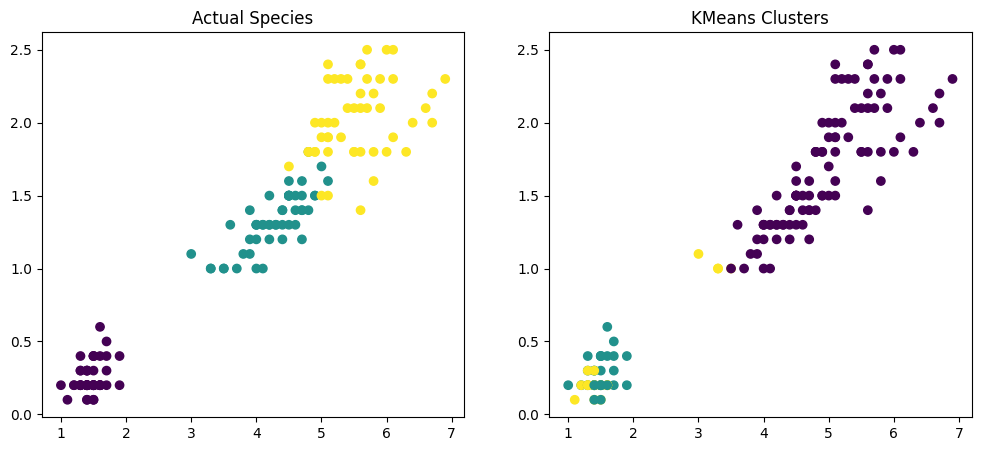

Cluster counts:
cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['actual_species'] = iris.target

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[iris.feature_names])

# KMeans with K=3 (we know there are 3 species!)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels
df['cluster'] = kmeans.labels_

# Visualize
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df["petal length (cm)"], 
            df["petal width (cm)"],
            c=df["actual_species"])
plt.title("Actual Species")

plt.subplot(1,2,2)
plt.scatter(df["petal length (cm)"], 
            df["petal width (cm)"],
            c=df["cluster"])
plt.title("KMeans Clusters")

plt.show()

print("Cluster counts:")
print(df['cluster'].value_counts())

In [3]:
# Compare clusters vs actual species
print(pd.crosstab(df['actual_species'], df['cluster']))

cluster          0   1   2
actual_species            
0                0  33  17
1               46   0   4
2               50   0   0


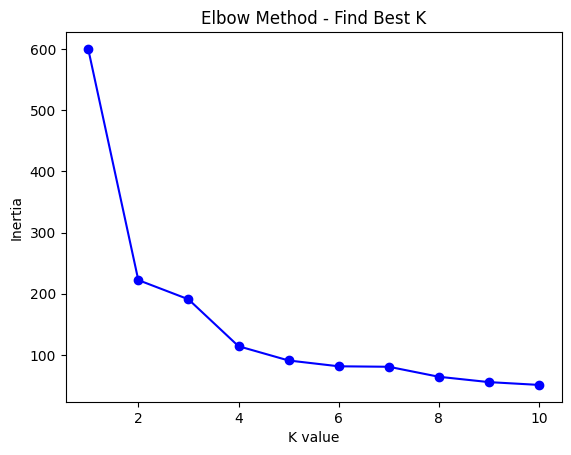

In [4]:
# Elbow method - find best K
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, 'bo-')
plt.xlabel("K value")
plt.ylabel("Inertia")
plt.title("Elbow Method - Find Best K")
plt.show()